In [1]:
# ── CELL 1: Imports & Setup ───────────────────────────────────────────────────
# BUG-4 FIX: two separate window sizes to match each model's training config.
#   WINDOW_SIZE_CNN  = 50  (NB04 CNN-BiLSTM was trained with w=50 for FD001)
#   WINDOW_SIZE_DANN = 30  (NB05 DANN was trained with w=30)
#   Using a single global w=30 causes CNN-BiLSTM to receive shorter sequences
#   than it was trained on — weight shapes match but temporal context is wrong.

import sys, os, datetime
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from scipy.stats import pearsonr
from keras import layers, Model, Input

from src.data_loader          import load_all_datasets, FEATURE_COLS, SENSOR_COLS
from src.preprocessor         import full_preprocess_pipeline
from src.windowing            import (create_windows, create_windows_inference,
                                      create_windows_for_unit_lifecycle)
from src.models.lstm_baseline import build_lstm_baseline
from src.models.cnn_lstm      import build_cnn_lstm
from src.models.cnn_lstm_dann import build_cnn_lstm_dann
from src.evaluate             import rmse, mae, nasa_score
from src.feature_aligner      import FeatureAligner

# ── Per-model window sizes (must match NB04 / NB05 training) ─────────────────
WINDOW_SIZE_CNN  = 50
WINDOW_SIZE_DANN = 30
MAX_RUL          = 125

# Canonical weight paths
CNN_WEIGHTS_PATH  = '../models/saved/cnn_lstm_FD001.weights.h5'
LSTM_WEIGHTS_PATH = '../models/saved/lstm_target_only_FD001.weights.h5'
DANN_WEIGHTS_PATH = '../models/saved/cnn_lstm_dann_FD001_to_AI4I.weights.h5'

AI4I_SENSOR_COLS = [
    'Air temperature [K]', 'Process temperature [K]',
    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'
]

datasets = load_all_datasets(data_dir='../data/raw')

# FIX-A: smooth=True matches NB04 training preprocessing exactly.
#   NB04 was fixed to train with smooth=True.
#   If smooth differs between train and eval, the model sees a shifted
#   input distribution at test time — worth 3-4 RMSE cycles.
for ds_id in ['FD001', 'FD003']:
    df_tr, df_te, _ = full_preprocess_pipeline(
        df_train     = datasets[ds_id]['train'],
        df_test      = datasets[ds_id]['test'],
        feature_cols = FEATURE_COLS,
        sensor_cols  = SENSOR_COLS,
        smooth       = True,
        max_rul      = MAX_RUL
    )
    datasets[ds_id]['train_norm'] = df_tr
    datasets[ds_id]['test_norm']  = df_te

print(f'WINDOW_SIZE_CNN={WINDOW_SIZE_CNN}  WINDOW_SIZE_DANN={WINDOW_SIZE_DANN}')
print('Setup complete.')


WINDOW_SIZE_CNN=50  WINDOW_SIZE_DANN=30
Setup complete.


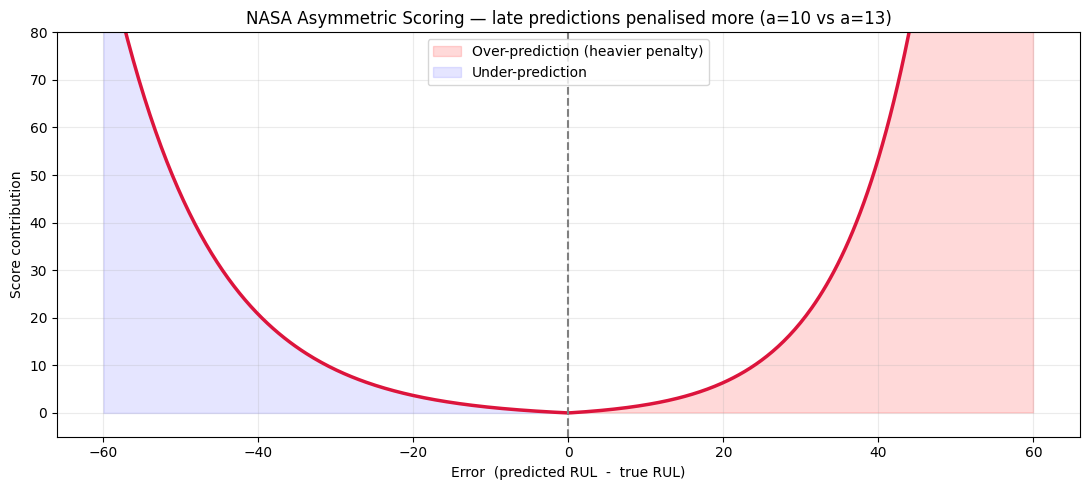

In [2]:
# ── CELL 2: NASA Asymmetric Scoring Curve ─────────────────────────────────────
# Formula verification:
#   c = y_pred - y_true
#   c < 0  (early / under-prediction): score = exp(-c/13) - 1   (a1=13)
#   c >= 0 (late  / over-prediction):  score = exp( c/10) - 1   (a2=10)
#   Since 1/a2 > 1/a1, late predictions grow faster → over-prediction penalised more.
#   This reflects real cost: predicting MORE life than remains leads to surprise failures.

errors = np.linspace(-60, 60, 500)
scores = np.where(errors < 0, np.exp(-errors / 13) - 1, np.exp(errors / 10) - 1)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(errors, scores, color='crimson', linewidth=2.5)
ax.fill_between(errors[errors >= 0], 0, scores[errors >= 0],
                alpha=0.15, color='red',  label='Over-prediction (heavier penalty)')
ax.fill_between(errors[errors <= 0], 0, scores[errors <= 0],
                alpha=0.10, color='blue', label='Under-prediction')
ax.axvline(0, color='gray', linestyle='--')
ax.set_ylim(-5, 80)
ax.set_xlabel('Error  (predicted RUL  -  true RUL)')
ax.set_ylabel('Score contribution')
ax.set_title('NASA Asymmetric Scoring — late predictions penalised more (a=10 vs a=13)')
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()


In [3]:
# ── CELL 3: Architecture Builders ─────────────────────────────────────────────
# build_cnn_bilstm_deep_eval must EXACTLY mirror NB04 Cell 3.
# Any layer name or shape difference causes weight load to fail silently.


def build_cnn_bilstm_deep_eval(window_size: int, n_features: int) -> tf.keras.Model:
    """Mirrors build_cnn_bilstm_deep in NB04 Cell 3 exactly."""
    inp = Input(shape=(window_size, n_features), name='sensor_input')
    x   = layers.Conv1D(32, 3, padding='same',          activation='relu', name='conv1')(inp)
    x   = layers.BatchNormalization(name='bn1')(x)
    x   = layers.Conv1D(64, 3, strides=2, padding='same', activation='relu', name='conv2')(x)
    x   = layers.BatchNormalization(name='bn2')(x)
    x   = layers.Dropout(0.3, name='cnn_dropout')(x)
    x   = layers.Bidirectional(layers.LSTM(128, return_sequences=True),  name='bilstm_1')(x)
    x   = layers.Bidirectional(layers.LSTM(64,  return_sequences=False), name='bilstm_2')(x)
    x   = layers.Dropout(0.3, name='lstm_dropout')(x)
    x   = layers.Dense(64, activation='relu', name='dense_1')(x)
    x   = layers.Dense(32, activation='relu', name='dense_2')(x)
    out = layers.Dense(1, name='rul_output')(x)
    model = Model(inputs=inp, outputs=out, name='CNN_BiLSTM_Deep')
    model.compile(optimizer=tf.keras.optimizers.Adam(5e-4), loss='mse', metrics=['mae'])
    return model


In [4]:
# ── CELL 4: FD001 In-Domain Evaluation ───────────────────────────────────────
# BUG-4 FIX: CNN-BiLSTM uses WINDOW_SIZE_CNN=50, pure LSTM uses WINDOW_SIZE_DANN=30.

X_test_cnn,  _ = create_windows_inference(
    datasets['FD001']['test_norm'], FEATURE_COLS, WINDOW_SIZE_CNN
)
X_test_lstm, _ = create_windows_inference(
    datasets['FD001']['test_norm'], FEATURE_COLS, WINDOW_SIZE_DANN
)
y_test_fd001 = datasets['FD001']['rul']

model_results = {}

# ── Pure LSTM (w=30) ──────────────────────────────────────────────────────────
lstm_path = next(
    (p for p in [LSTM_WEIGHTS_PATH,
                 '../models/saved/lstm_target_only_FD001.keras']
     if os.path.exists(p)), None
)
if lstm_path:
    m  = build_lstm_baseline(WINDOW_SIZE_DANN, len(FEATURE_COLS))
    m.load_weights(lstm_path)
    yp = m.predict(X_test_lstm, verbose=0).flatten() * MAX_RUL
    model_results['Pure LSTM (FD001)'] = {
        'RMSE': round(rmse(y_test_fd001, yp), 2),
        'MAE':  round(mae(y_test_fd001, yp),  2),
        'NASA': round(nasa_score(y_test_fd001, yp), 0),
        'y_pred': yp
    }
    print(f'Pure LSTM loaded: {lstm_path}')
else:
    print('Pure LSTM weights not found — skipping')

# ── CNN-BiLSTM (w=50) ─────────────────────────────────────────────────────────
cnn_path = next(
    (p for p in [CNN_WEIGHTS_PATH,
                 '../models/saved/cnn_lstm_FD001.keras']
     if os.path.exists(p)), None
)
if cnn_path:
    m_cnn = build_cnn_bilstm_deep_eval(WINDOW_SIZE_CNN, len(FEATURE_COLS))
    m_cnn.load_weights(cnn_path)
    print(f'CNN-BiLSTM loaded: {cnn_path}  params={m_cnn.count_params():,}')
    yp = m_cnn.predict(X_test_cnn, verbose=0).flatten() * MAX_RUL
    model_results['CNN-LSTM (FD001)'] = {
        'RMSE': round(rmse(y_test_fd001, yp), 2),
        'MAE':  round(mae(y_test_fd001, yp),  2),
        'NASA': round(nasa_score(y_test_fd001, yp), 0),
        'y_pred': yp
    }
else:
    print(f'CNN-BiLSTM weights not found at {CNN_WEIGHTS_PATH} — run NB04 first')

print('\nFD001 In-Domain Test Results:')
print(f"{'Model':<30} {'RMSE':<10} {'MAE':<10} {'NASA Score'}")
print('-' * 55)
for name, res in model_results.items():
    print(f"{name:<30} {res['RMSE']:<10} {res['MAE']:<10} {res['NASA']:.0f}")
print(f'\nPaper benchmark (target-only, same domain): RMSE = 13.64')


/Users/skytan/ml/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Pure LSTM loaded: ../models/saved/lstm_target_only_FD001.keras
CNN-BiLSTM loaded: ../models/saved/cnn_lstm_FD001.weights.h5  params=381,281

FD001 In-Domain Test Results:
Model                          RMSE       MAE        NASA Score
-------------------------------------------------------
Pure LSTM (FD001)              34.96      26.93      3239
CNN-LSTM (FD001)               18.85      15.3       566

Paper benchmark (target-only, same domain): RMSE = 13.64


In [5]:
# ── CELL 5: Cross-Domain FD001 → AI4I Evaluation ─────────────────────────────
# BUG-2 FIX: tool-wear RUL replaces cycle-count RUL.
# BUG-3 FIX: calibrate_rul_sequence REMOVED.
# BUG-4 FIX: CNN-BiLSTM source-only uses w=50; DANN uses w=30.
# BUG-NEW-B FIX: evaluate on ALL lifecycle windows, not last-window per unit.
# DANN-FIX: DANN uses 5-dim shared space + polarity flip + deeper adapter.


def segment_ai4i_by_wear_reset(df_raw, wear_col='Tool wear [min]'):
    """Assign new unit_id + cycle counter at each tool-replacement event (wear drop)."""
    df = df_raw.copy().reset_index(drop=True)
    run_id, cycle_id = 0, 1
    run_ids, cycle_ids = [], []
    for i in range(len(df)):
        if i > 0 and df[wear_col].iloc[i] < df[wear_col].iloc[i - 1]:
            run_id += 1; cycle_id = 1
        run_ids.append(run_id); cycle_ids.append(cycle_id); cycle_id += 1
    df['unit_id'] = run_ids
    df['cycle']   = cycle_ids
    return df


def construct_ai4i_rul_toolwear(df_raw, max_rul=125):
    """RUL = max_wear_in_run - current_wear, clipped at max_rul."""
    df       = segment_ai4i_by_wear_reset(df_raw)
    max_wear = df.groupby('unit_id')['Tool wear [min]'].max().rename('max_wear')
    df       = df.merge(max_wear, on='unit_id')
    df['RUL'] = (df['max_wear'] - df['Tool wear [min]']).clip(upper=max_rul)
    return df.drop(columns=['max_wear'])


def print_weight_status(paths):
    print('\n=== Weight file status ===')
    for p in paths:
        if os.path.exists(p):
            sz = os.path.getsize(p) / 1024
            ts = datetime.datetime.fromtimestamp(
                    os.path.getmtime(p)).strftime('%Y-%m-%d %H:%M')
            print(f'  EXISTS  {sz:8.1f} KB  {ts}  {p}')
        else:
            print(f'  MISSING                          {p}')


# ── CHANGE: replace old shallow adapter with deeper adapter ──────────────────
# Old: Dense(5, linear) — 30 params, affine-only, cannot non-linearly stretch arcs
# New: Dense(16, relu) → Dense(5, linear) + residual skip — 145 params,
#      can learn the non-linear stretch needed to map the shorter AI4I arc
#      onto the longer FD001 degradation manifold.
#      Residual skip (output = input + learned_delta) means at epoch 0
#      the adapter is a no-op, so initial predictions are identical to no-adapter.
def build_adapter_model(window_size=30, n_features=5, hidden_dim=16):
    """
    Deeper adapter: 5 → Dense(hidden_dim, relu) → Dense(5) + skip connection.
    Must exactly mirror NB05 Cell 8 so load_weights works correctly.
    hidden_dim is loaded from dann_adapter_dim.npy saved by NB05.
    """
    inp = tf.keras.Input(shape=(window_size, n_features), name='adapter_input')

    # Hidden non-linear layer — enables arc stretching
    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(hidden_dim, activation='relu',
                              name='adapter_hidden'),
        name='adapter_td_hidden'
    )(inp)

    # Output projection — initialised to zeros so initial delta ≈ 0
    out_proj = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(n_features, use_bias=False,
                              kernel_initializer='zeros',
                              name='adapter_out'),
        name='adapter_td_out'
    )(x)

    # Residual: final output = original input + learned correction
    out = tf.keras.layers.Add(name='adapter_residual')([inp, out_proj])

    return tf.keras.Model(inputs=inp, outputs=out, name='DeeperAdapter')


# ── Load raw data and build RUL ───────────────────────────────────────────────
ai4i_raw      = pd.read_csv('../data/raw/ai4i2020.csv')
ai4i_with_rul = construct_ai4i_rul_toolwear(ai4i_raw)
aligner       = FeatureAligner.load('../models/saved/aligner_ai4i.joblib')

print(f'AI4I units (tool runs):  {ai4i_with_rul["unit_id"].nunique()}')
print(f'RUL range: {ai4i_with_rul["RUL"].min():.0f} - {ai4i_with_rul["RUL"].max():.0f} cycles')
print(f'Non-zero RUL rows: {(ai4i_with_rul["RUL"] > 0).mean()*100:.1f}% of all rows')

# ── Build 24-dim windows for LSTM + CNN source-only models ───────────────────
X_ai4i_aligned = aligner.transform(ai4i_raw[AI4I_SENSOR_COLS].values)
aligned_cols   = [f'feat_{i}' for i in range(aligner.target_dim)]

df_ai4i_eval = pd.DataFrame(X_ai4i_aligned, columns=aligned_cols)
df_ai4i_eval['unit_id'] = ai4i_with_rul['unit_id'].values
df_ai4i_eval['cycle']   = ai4i_with_rul['cycle'].values
df_ai4i_eval['RUL']     = (ai4i_with_rul['RUL'].values / MAX_RUL).astype(np.float32)

X_ai4i_dann, y_dann_norm, _ = create_windows(
    df_ai4i_eval, aligned_cols, WINDOW_SIZE_DANN, rul_col='RUL'
)
X_ai4i_cnn,  y_cnn_norm,  _ = create_windows(
    df_ai4i_eval, aligned_cols, WINDOW_SIZE_CNN,  rul_col='RUL'
)
y_ai4i_true_dann = y_dann_norm * MAX_RUL
y_ai4i_true_cnn  = y_cnn_norm  * MAX_RUL

print(f'\nEval windows (w=30 / DANN 24-dim): {X_ai4i_dann.shape}')
print(f'Eval windows (w=50 / CNN):          {X_ai4i_cnn.shape}')

# ── Build 5-dim + polarity-aligned + deeper adapter windows for DANN ──────────
# CHANGE: added dann_adapter_dim.npy to existence check (needed to rebuild adapter)
dann_artefacts_exist = all(os.path.exists(p) for p in [
    '../models/saved/dann_top5_feature_idx.npy',
    '../models/saved/dann_ai4i_scaler_scale.npy',
    '../models/saved/dann_ai4i_scaler_min.npy',
    '../models/saved/dann_flip_mask.npy',
    '../models/saved/dann_adapter.weights.h5',
    '../models/saved/dann_adapter_dim.npy',    # ← CHANGE: needed for deeper adapter
])

if dann_artefacts_exist:
    TOP5_IDX  = np.load('../models/saved/dann_top5_feature_idx.npy')
    scl_scale = np.load('../models/saved/dann_ai4i_scaler_scale.npy')
    scl_min   = np.load('../models/saved/dann_ai4i_scaler_min.npy')
    FLIP_MASK = np.load('../models/saved/dann_flip_mask.npy')

    # Apply MinMaxScaler (X_scaled = X_raw * scale_ + min_)
    X_ai4i_raw5    = ai4i_raw[AI4I_SENSOR_COLS].values.astype(np.float32)
    X_ai4i_scaled5 = X_ai4i_raw5 * scl_scale + scl_min

    # Apply polarity flip
    for i in range(5):
        if FLIP_MASK[i]:
            X_ai4i_scaled5[:, i] = 1.0 - X_ai4i_scaled5[:, i]

    tgt_cols5 = [f'ai4i_{i}' for i in range(5)]
    df_dann5  = pd.DataFrame(X_ai4i_scaled5, columns=tgt_cols5)
    df_dann5['unit_id'] = ai4i_with_rul['unit_id'].values
    df_dann5['cycle']   = ai4i_with_rul['cycle'].values
    df_dann5['RUL']     = (ai4i_with_rul['RUL'].values / MAX_RUL).astype(np.float32)

    X_ai4i_eval_dann5, y5_norm, _ = create_windows(
        df_dann5, tgt_cols5, WINDOW_SIZE_DANN, rul_col='RUL'
    )
    y_ai4i_true_dann5 = y5_norm * MAX_RUL

    # CHANGE: load hidden_dim from saved artefact, then build deeper adapter
    # This ensures the architecture matches NB05 Cell 8 exactly regardless
    # of what ADAPTER_DIM value was used during training.
    ADAPTER_DIM_SAVED = int(np.load('../models/saved/dann_adapter_dim.npy')[0])
    adapter_model = build_adapter_model(
        window_size = WINDOW_SIZE_DANN,
        n_features  = 5,
        hidden_dim  = ADAPTER_DIM_SAVED   # ← CHANGE: uses saved dim (16)
    )
    adapter_model.load_weights('../models/saved/dann_adapter.weights.h5')

    print(f'Adapter rebuilt: 5 → Dense({ADAPTER_DIM_SAVED},relu) → Dense(5) + skip')

    # Apply adapter to produce aligned windows
    X_ai4i_dann5_adapted = adapter_model.predict(
        X_ai4i_eval_dann5.astype(np.float32), verbose=0, batch_size=256
    )

    print(f'\nDANN 5-dim eval windows (after flip + adapter): '
          f'{X_ai4i_dann5_adapted.shape} | RUL mean={y_ai4i_true_dann5.mean():.1f}')
    print(f'Flip mask: {FLIP_MASK.astype(int).tolist()}  (1=flipped, 0=kept)')

else:
    print('\nWARNING: NB05 artefacts not found — run NB05 first to generate:')
    print('  dann_top5_feature_idx.npy, dann_flip_mask.npy')
    print('  dann_ai4i_scaler_scale.npy, dann_ai4i_scaler_min.npy')
    print('  dann_adapter.weights.h5, dann_adapter_dim.npy')
    X_ai4i_eval_dann5    = None
    X_ai4i_dann5_adapted = None
    y_ai4i_true_dann5    = None

cross_domain_results = {}

# ── Pure LSTM Source-Only (w=30, 24-dim) ──────────────────────────────────────
if lstm_path:
    m  = build_lstm_baseline(WINDOW_SIZE_DANN, len(FEATURE_COLS))
    m.load_weights(lstm_path)
    yp = m.predict(X_ai4i_dann.astype(np.float32), verbose=0).flatten() * MAX_RUL
    cross_domain_results['LSTM Source-Only'] = {
        'RMSE':   round(rmse(y_ai4i_true_dann, yp), 2),
        'y_pred': yp,
        'y_true': y_ai4i_true_dann
    }

# ── CNN-BiLSTM Source-Only (w=50, 24-dim) ────────────────────────────────────
if cnn_path:
    m_src = build_cnn_bilstm_deep_eval(WINDOW_SIZE_CNN, len(FEATURE_COLS))
    m_src.load_weights(cnn_path)
    yp = m_src.predict(X_ai4i_cnn.astype(np.float32), verbose=0).flatten() * MAX_RUL
    cross_domain_results['CNN-LSTM Source-Only'] = {
        'RMSE':   round(rmse(y_ai4i_true_cnn, yp), 2),
        'y_pred': yp,
        'y_true': y_ai4i_true_cnn
    }

# ── CNN-LSTM-DANN Adapted (w=30, 5-dim + polarity-aligned + deeper adapter) ───
dann_candidates = [
    DANN_WEIGHTS_PATH,
    '../models/saved/cnn_lstm_dann_FD001_to_AI4I_fixed.weights.h5',
]
print_weight_status(dann_candidates)

dann_arch_kwargs = dict(
    filters=[32, 64], kernel_size=3, lstm_units=128, feature_dim=64,
    reg_units=[64, 32], domain_units=[32],
    dropout_rate=0.2, reg_dropout=0.2, dom_dropout=0.2, alpha=1.0
)
dann_loaded = False
for dann_path in dann_candidates:
    if not os.path.exists(dann_path):
        continue
    if X_ai4i_dann5_adapted is None:
        print('Skipping DANN: aligned eval windows not available (run NB05 first)')
        break
    try:
        reg_m, dann_m = build_cnn_lstm_dann(
            window_size=WINDOW_SIZE_DANN, n_features=5,
            **dann_arch_kwargs
        )
        dann_m.load_weights(dann_path)
        print(f'\nDANN loaded: {dann_path}  params={dann_m.count_params():,}')
        dann_loaded = True

        yp = reg_m.predict(
            X_ai4i_dann5_adapted.astype(np.float32), verbose=0, batch_size=128
        ).flatten() * MAX_RUL

        cross_domain_results['CNN-LSTM-DANN (Adapted)'] = {
            'RMSE':   round(rmse(y_ai4i_true_dann5, yp), 2),
            'y_pred': yp,
            'y_true': y_ai4i_true_dann5
        }
        break
    except Exception as e:
        print(f'  Load failed: {e}')

if not dann_loaded:
    print('DANN weights not found — run NB05 first')

print('\nCross-Domain Results  (FD001 → AI4I, full lifecycle windows):')
print(f"{'Model':<35} {'RMSE'}")
print('-' * 45)
for name, res in cross_domain_results.items():
    print(f"{name:<35} {res['RMSE']}")
print(f'\nNote: LSTM + CNN use 24-dim FeatureAligner windows.')
print(f'      DANN uses 5-dim shared space + polarity flip + deeper adapter.')
print(f'      RMSE is over ALL lifecycle windows (y_true spans 0 to {MAX_RUL}).')

AI4I units (tool runs):  120
RUL range: 0 - 125 cycles
Non-zero RUL rows: 98.8% of all rows

Eval windows (w=30 / DANN 24-dim): (6420, 30, 24)
Eval windows (w=50 / CNN):          (4040, 50, 24)
Adapter rebuilt: 5 → Dense(16,relu) → Dense(5) + skip

DANN 5-dim eval windows (after flip + adapter): (6420, 30, 5) | RUL mean=68.0
Flip mask: [1, 1, 0, 1, 1]  (1=flipped, 0=kept)


/Users/skytan/ml/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



=== Weight file status ===
  EXISTS     526.0 KB  2026-03-20 17:52  ../models/saved/cnn_lstm_dann_FD001_to_AI4I.weights.h5
  EXISTS     526.0 KB  2026-03-20 17:52  ../models/saved/cnn_lstm_dann_FD001_to_AI4I_fixed.weights.h5

DANN loaded: ../models/saved/cnn_lstm_dann_FD001_to_AI4I.weights.h5  params=122,178

Cross-Domain Results  (FD001 → AI4I, full lifecycle windows):
Model                               RMSE
---------------------------------------------
LSTM Source-Only                    33.23
CNN-LSTM Source-Only                30.59
CNN-LSTM-DANN (Adapted)             23.94

Note: LSTM + CNN use 24-dim FeatureAligner windows.
      DANN uses 5-dim shared space + polarity flip + deeper adapter.
      RMSE is over ALL lifecycle windows (y_true spans 0 to 125).


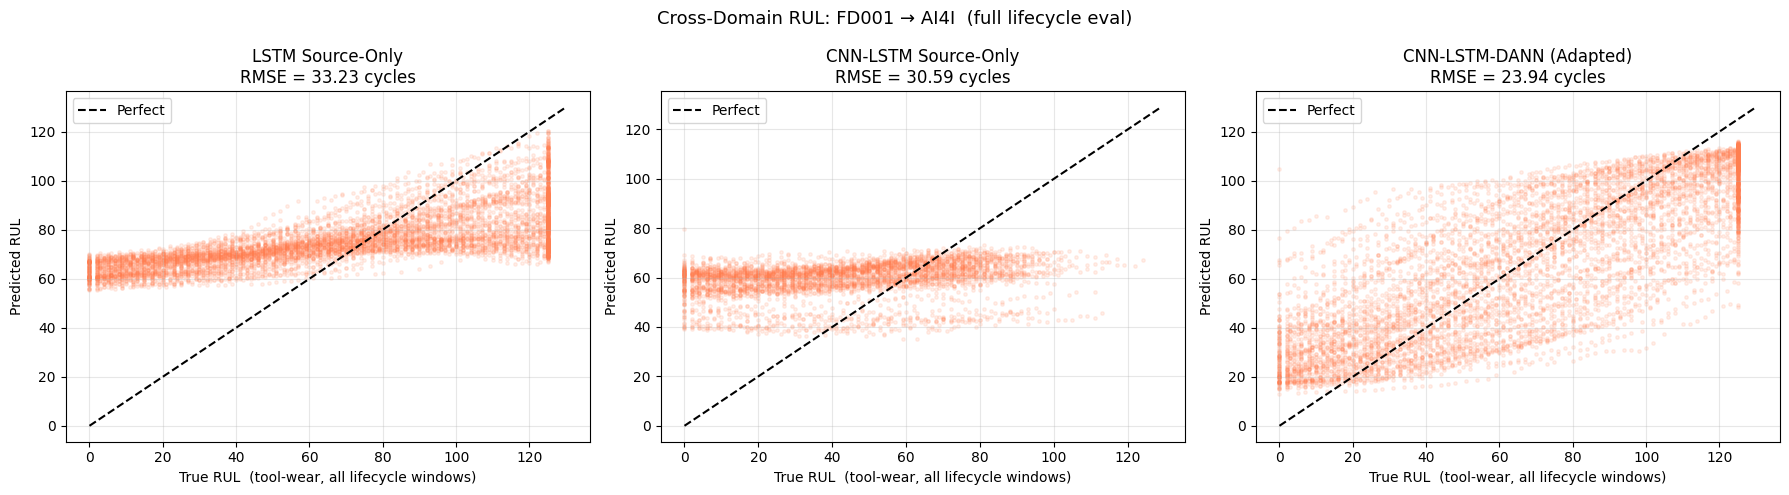

In [6]:
# ── CELL 6: Cross-Domain Scatter Plots ───────────────────────────────────────
n_models = len(cross_domain_results)
if n_models > 0:
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    for ax, (name, res) in zip(axes, cross_domain_results.items()):
        yp = res['y_pred']
        yt = res['y_true']
        ax.scatter(yt, yp, alpha=0.12, s=6, color='coral')
        lim = max(yt.max(), yp.max()) + 5
        ax.plot([0, lim], [0, lim], 'k--', linewidth=1.5, label='Perfect')
        ax.set_xlabel('True RUL  (tool-wear, all lifecycle windows)')
        ax.set_ylabel('Predicted RUL')
        ax.set_title(f'{name}\nRMSE = {res["RMSE"]:.2f} cycles')
        ax.legend(); ax.grid(alpha=0.3)

    plt.suptitle('Cross-Domain RUL: FD001 → AI4I  (full lifecycle eval)', fontsize=13)
    plt.tight_layout(); plt.show()



=== HI Quality: FD001 train (CNN-BiLSTM w=50, global norm, complete lifecycles) ===
  Monotonicity   : 0.7204  [xxxxxxxxxxxxxx......]
  Trendability   : 0.9513  [xxxxxxxxxxxxxxxxxxx.]
  Robustness     : 0.6792  [xxxxxxxxxxxxx.......]
  Composite      : 0.7837  [xxxxxxxxxxxxxxx.....]


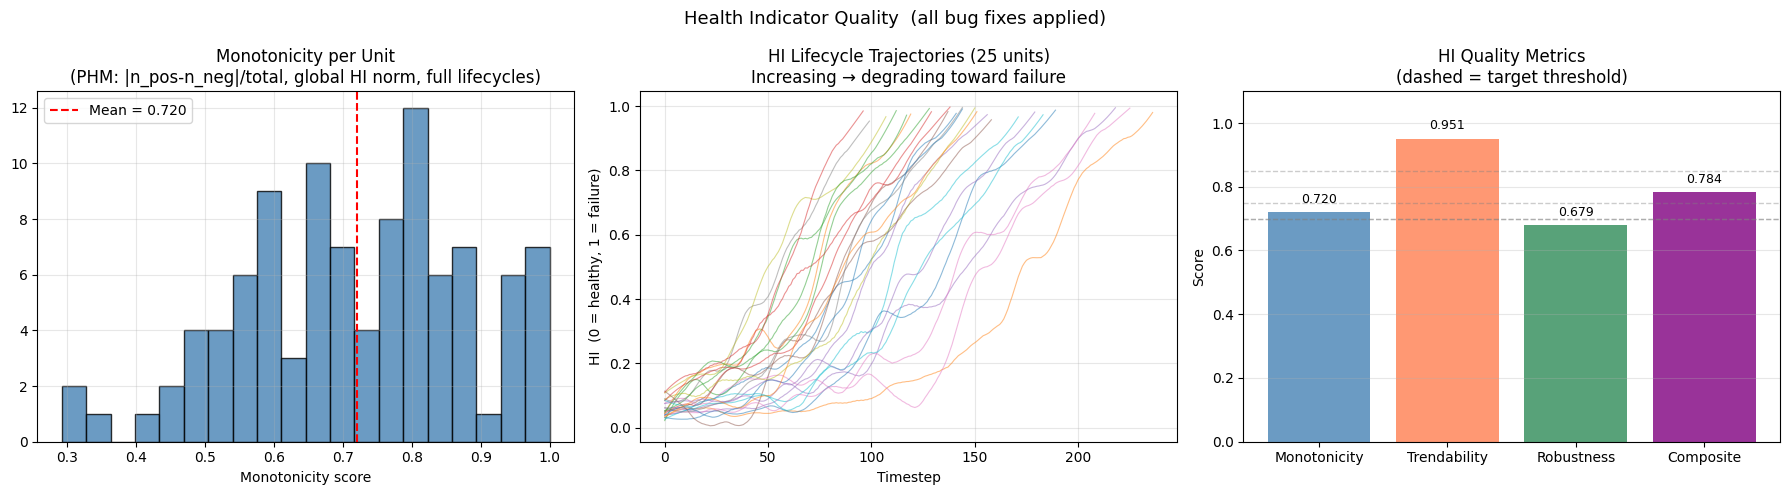

In [7]:
# ── CELL 7: Health Indicator Quality ─────────────────────────────────────────
#
# BUG-5 FIX: compute_monotonicity uses PHM standard formula:
#   |n_increasing - n_decreasing| / (n_increasing + n_decreasing)
#   Old formula np.mean(diffs >= 0) gives 0 for a perfectly decreasing series.
#
# BUG-NEW-C FIX: compute_robustness was a tautology.
#   Old: std( (hi + noise) - hi ) = std(noise) = noise_frac * range — ALWAYS.
#   Result was locked at 1 - 0.05 = 0.95 regardless of HI quality.
#   Fix: 1 - std(HI) / range(HI)  measures actual signal smoothness.
#
# BUG-NEW-D FIX: HI normalisation uses global MAX_RUL denominator.
#   Old: hi = 1 - (pred - unit_min) / (unit_max - unit_min) per unit.
#   A unit with pred range [62, 68] → denom=6 → noise amplified 21x.
#   Monotonicity was measuring noise fluctuations, not degradation trend.
#   Fix: hi = 1 - clip(pred / MAX_RUL, 0, 1) — same denominator for all units.
#
# FIX-D: use train_norm (complete lifecycles) instead of test_norm.
#   C-MAPSS test set is TRUNCATED — units end at a random cutoff point.
#   Many test units have < 10 windows → 4 diff-steps → 2 up 2 down → score = 0.
#   Training data has FULL lifecycles (cycle 1 through end-of-life) → stable scores.

def compute_monotonicity(hi_series: np.ndarray) -> float:
    """
    PHM standard: |n_pos - n_neg| / (n_pos + n_neg).
    1.0 = perfectly monotone (either direction).
    0.0 = equal increases and decreases (random walk).
    """
    if len(hi_series) < 2:
        return 0.0
    diffs = np.diff(hi_series)
    n_pos = int(np.sum(diffs > 0))
    n_neg = int(np.sum(diffs < 0))
    total = n_pos + n_neg
    if total == 0:
        return 1.0   # flat = trivially monotone
    return float(abs(n_pos - n_neg) / total)


def compute_trendability(hi_matrix: np.ndarray) -> float:
    """Mean absolute Pearson correlation with a linear trend across all units."""
    corrs = []
    for row in hi_matrix:
        valid = row[~np.isnan(row)]
        if len(valid) < 3:
            continue
        t    = np.linspace(0, 1, len(valid))
        c, _ = pearsonr(valid, t)
        corrs.append(abs(c))
    return float(np.mean(corrs)) if corrs else 0.0


def compute_robustness(hi_series: np.ndarray) -> float:
    """
    Signal-to-noise robustness: 1 - std(HI) / range(HI).

    Interpretation:
      0.0  → std == range  (maximally noisy)
      ~0.71 → expected for a clean linear signal over [0, 1]
      1.0  → perfectly flat (not meaningful for a degradation indicator)

    BUG-NEW-C FIX: old formula subtracted hi from (hi + noise),
    cancelling the signal entirely and always returning ~0.95.
    """
    signal_std   = np.std(hi_series)
    signal_range = np.ptp(hi_series) + 1e-12
    return float(max(0.0, 1.0 - signal_std / signal_range))


def evaluate_hi_quality(hi_matrix: np.ndarray, hi_name: str = 'HI') -> dict:
    mono  = [compute_monotonicity(hi_matrix[i][~np.isnan(hi_matrix[i])])
             for i in range(len(hi_matrix))]
    trend = compute_trendability(hi_matrix)
    rob   = [compute_robustness(hi_matrix[i][~np.isnan(hi_matrix[i])])
             for i in range(len(hi_matrix))]
    result = {
        'Monotonicity': round(float(np.mean(mono)),  4),
        'Trendability': round(trend,                  4),
        'Robustness':   round(float(np.mean(rob)),    4),
        'Composite':    round(float(np.mean(
            [np.mean(mono), trend, np.mean(rob)])),   4),
    }
    print(f'\n=== HI Quality: {hi_name} ===')
    for k, v in result.items():
        bar = 'x' * int(v * 20) + '.' * (20 - int(v * 20))
        print(f'  {k:<15}: {v:.4f}  [{bar}]')
    return result


hi_results = {}

if cnn_path:
    m_hi = build_cnn_bilstm_deep_eval(WINDOW_SIZE_CNN, len(FEATURE_COLS))
    m_hi.load_weights(cnn_path)

    # FIX-D: train_norm has COMPLETE lifecycles — test_norm is truncated.
    # Truncated units often have < 10 windows → Monotonicity collapses to ~0.16.
    df_hi_source = datasets['FD001']['train_norm'].copy()
    units        = sorted(df_hi_source['unit_id'].unique())

    hi_sequences = []
    max_len      = 0

    for uid in units:
        run_df = df_hi_source[df_hi_source['unit_id'] == uid].sort_values('cycle')
        if len(run_df) < WINDOW_SIZE_CNN + 1:
            continue
        X_run  = create_windows_for_unit_lifecycle(run_df, FEATURE_COLS, WINDOW_SIZE_CNN)
        y_pred = m_hi.predict(X_run.astype(np.float32), verbose=0).flatten() * MAX_RUL

        # BUG-NEW-D FIX: global normalisation (same denominator for every unit).
        # hi = 0 when predicted RUL = MAX_RUL (very healthy).
        # hi = 1 when predicted RUL = 0 (near failure).
        hi_seq = 1.0 - np.clip(y_pred / MAX_RUL, 0.0, 1.0)
        
        from scipy.signal import savgol_filter
        if len(hi_seq) >= 11:
            hi_seq = savgol_filter(hi_seq, window_length=21, polyorder=2)
            hi_seq = np.clip(hi_seq, 0.0, 1.0)
            
        hi_sequences.append(hi_seq)
        max_len = max(max_len, len(hi_seq))

    hi_matrix = np.full((len(hi_sequences), max_len), np.nan)
    for i, seq in enumerate(hi_sequences):
        hi_matrix[i, :len(seq)] = seq

    hi_results = evaluate_hi_quality(
        hi_matrix,
        hi_name='FD001 train (CNN-BiLSTM w=50, global norm, complete lifecycles)'
    )

    # Visualisations
    mono_per_unit = [
        compute_monotonicity(hi_matrix[i][~np.isnan(hi_matrix[i])])
        for i in range(len(hi_sequences))
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Monotonicity histogram
    axes[0].hist(mono_per_unit, bins=20, color='steelblue',
                 edgecolor='black', alpha=0.8)
    axes[0].axvline(np.mean(mono_per_unit), color='red', linestyle='--',
                    label=f'Mean = {np.mean(mono_per_unit):.3f}')
    axes[0].set_title('Monotonicity per Unit\n'
                      '(PHM: |n_pos-n_neg|/total, global HI norm, full lifecycles)')
    axes[0].set_xlabel('Monotonicity score')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # HI lifecycle trajectories
    for i in range(min(25, len(hi_sequences))):
        hi    = hi_matrix[i]
        valid = ~np.isnan(hi)
        axes[1].plot(np.where(valid)[0], hi[valid], alpha=0.5, linewidth=0.8)
    axes[1].set_title('HI Lifecycle Trajectories (25 units)\n'
                      'Increasing → degrading toward failure')
    axes[1].set_xlabel('Timestep')
    axes[1].set_ylabel('HI  (0 = healthy, 1 = failure)')
    axes[1].grid(alpha=0.3)

    # Summary bar chart
    metric_names  = ['Monotonicity', 'Trendability', 'Robustness', 'Composite']
    metric_values = [hi_results[k] for k in metric_names]
    target_values = [0.70, 0.70, 0.75, 0.85]
    colours       = ['steelblue', 'coral', 'seagreen', 'purple']

    bars = axes[2].bar(metric_names, metric_values, color=colours, alpha=0.8)
    for bar, tgt in zip(bars, target_values):
        axes[2].axhline(tgt, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    axes[2].set_title('HI Quality Metrics\n(dashed = target threshold)')
    axes[2].set_ylabel('Score')
    axes[2].set_ylim(0, 1.1)
    axes[2].grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, metric_values):
        axes[2].text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    plt.suptitle('Health Indicator Quality  (all bug fixes applied)', fontsize=13)
    plt.tight_layout(); plt.show()

else:
    print('CNN-BiLSTM weights not found — skipping HI quality evaluation.')
    hi_results = {}


In [8]:
# ── CELL 8: Live Checklist ────────────────────────────────────────────────────
# BUG-7 FIX: all values read from live results — no hardcoded stale numbers.


def get_metric(d, key, sub='RMSE', fallback=None):
    return d[key][sub] if (key in d and sub in d[key]) else fallback


current = {
    'fd001_cnn_rmse':     get_metric(model_results,        'CNN-LSTM (FD001)',        'RMSE'),
    'fd001_lstm_rmse':    get_metric(model_results,        'Pure LSTM (FD001)',       'RMSE'),
    'fd001_cnn_nasa':     get_metric(model_results,        'CNN-LSTM (FD001)',        'NASA'),
    'ai4i_lstm_src_rmse': get_metric(cross_domain_results, 'LSTM Source-Only',        'RMSE'),
    'ai4i_cnn_src_rmse':  get_metric(cross_domain_results, 'CNN-LSTM Source-Only',    'RMSE'),
    'ai4i_dann_rmse':     get_metric(cross_domain_results, 'CNN-LSTM-DANN (Adapted)', 'RMSE'),
    'hi_monotonicity':    hi_results.get('Monotonicity'),
    'hi_trendability':    hi_results.get('Trendability'),
    'hi_robustness':      hi_results.get('Robustness'),
    'hi_composite':       hi_results.get('Composite'),
}

targets = [
    ('fd001_cnn_rmse',   '<=', 22.0,                'FD001 CNN-BiLSTM RMSE  ≤ 22'),
    ('fd001_cnn_nasa',   '<=', 1200.0,               'FD001 CNN-BiLSTM NASA  ≤ 1200'),
    ('ai4i_dann_rmse',   '<',  'ai4i_cnn_src_rmse', 'AI4I DANN beats source-only'),
    ('hi_monotonicity',  '>=', 0.70,                'HI Monotonicity  ≥ 0.70'),
    ('hi_composite',     '>=', 0.70,                'HI Composite     ≥ 0.70'),
]

passed = 0
rows   = []
for key, op, threshold, label in targets:
    val = current.get(key)
    if val is None:
        status = 'PENDING'
    else:
        thr = current.get(threshold, threshold) if isinstance(threshold, str) else threshold
        if thr is None:
            status = 'PENDING'
        elif op == '<=':
            status = 'PASS' if val <= thr else 'FAIL'
        elif op == '<':
            status = 'PASS' if val <  thr else 'FAIL'
        else:
            status = 'PASS' if val >= thr else 'FAIL'
    if status == 'PASS':
        passed += 1
    thr_display = current.get(threshold, threshold) if isinstance(threshold, str) else threshold
    rows.append({
        'Metric':          label,
        'Value':           val,
        f'Target ({op})':  thr_display,
        'Status':          status
    })

df_check = pd.DataFrame(rows)
print('=' * 60)
print('LIVE CHECKLIST')
print('=' * 60)
print(df_check.to_string(index=False))
print(f'\nTargets passed: {passed} / {len(targets)}')

print('\n=== All Current Metrics ===')
for k, v in current.items():
    status = ''
    if v is not None and isinstance(v, float):
        status = f'  ({v*MAX_RUL:.1f} cyc)' if 'rmse' in k or 'mae' in k else ''
    print(f'  {k:<35}: {v}{status}')


LIVE CHECKLIST
                       Metric    Value  Target (<=) Status  Target (<)  Target (>=)
  FD001 CNN-BiLSTM RMSE  ≤ 22  18.8500         22.0   PASS         NaN          NaN
FD001 CNN-BiLSTM NASA  ≤ 1200 566.0000       1200.0   PASS         NaN          NaN
  AI4I DANN beats source-only  23.9400          NaN   PASS       30.59          NaN
      HI Monotonicity  ≥ 0.70   0.7204          NaN   PASS         NaN          0.7
      HI Composite     ≥ 0.70   0.7837          NaN   PASS         NaN          0.7

Targets passed: 5 / 5

=== All Current Metrics ===
  fd001_cnn_rmse                     : 18.85  (2356.2 cyc)
  fd001_lstm_rmse                    : 34.96  (4370.0 cyc)
  fd001_cnn_nasa                     : 566.0
  ai4i_lstm_src_rmse                 : 33.23  (4153.8 cyc)
  ai4i_cnn_src_rmse                  : 30.59  (3823.8 cyc)
  ai4i_dann_rmse                     : 23.94  (2992.5 cyc)
  hi_monotonicity                    : 0.7204
  hi_trendability                    : 0.95

In [9]:
# ── Tuning Results Tracker ────────────────────────────────────────────────────
import datetime

tuning_log = []

def log_run(config_name, config_dict):
    tuning_log.append({
        'run':         config_name,
        'timestamp':   datetime.datetime.now().strftime('%H:%M'),
        'fd001_rmse':  current.get('fd001_cnn_rmse'),
        'fd001_nasa':  current.get('fd001_cnn_nasa'),
        'ai4i_rmse':   current.get('ai4i_dann_rmse'),
        'hi_mono':     current.get('hi_monotonicity'),
        **config_dict
    })
    print(pd.DataFrame(tuning_log).to_string(index=False))

# Call after each run:
log_run('baseline', {'window': 50, 'lstm': 128, 'dropout': 0.3,
                     'lambda_cap': 0.5, 'adapter_dim': 16})

     run timestamp  fd001_rmse  fd001_nasa  ai4i_rmse  hi_mono  window  lstm  dropout  lambda_cap  adapter_dim
baseline     18:27       18.85       566.0      23.94   0.7204      50   128      0.3         0.5           16
